In [1]:
import loompy as lp
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pdir = "/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/"
MODULE_PATH = pdir+"processed-data/09_DEG_GRN/AUCell_modules/"

In [3]:
def extract_aucell(cluster):
    
    lf = lp.connect(MODULE_PATH+"spe-n119_seurat-label-"+cluster+"_13162-genes_no-lowUMI_logcounts_modules-DEG-subset-refined_AUCell-fixed-thold-05.loom", mode='r+', validate=False)
    auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
    cell_mtx = pd.DataFrame({"seurat_label": lf.ca.seurat_label, "smoothed_k9_1663": lf.ca.smoothed_k9_1663, #"custom_cluster": cluster,
                             "sex": lf.ca.sex, "condition": lf.ca.condition, "nGene": lf.ca.nGene, "nUMI": lf.ca.nUMI}, index=lf.ca.CellID)
    lf.close()
    
    #signature_column_names = list(auc_mtx.select_dtypes('number').columns)
    #signature_column_names = list(map(lambda s: s[12:], signature_column_names))
    #auc_mtx.columns = signature_column_names
    
    return auc_mtx, cell_mtx

In [4]:
auc_mv, cell_mv = extract_aucell("Micro.Vasc")
auc_ast, cell_ast = extract_aucell("Astro")
auc_l23, cell_l23 = extract_aucell("L2.3")
auc_l4, cell_l4 = extract_aucell("L4")
auc_inh, cell_inh = extract_aucell("Inhb")
auc_l5, cell_l5 = extract_aucell("L5")
auc_l6, cell_l6 = extract_aucell("L6")
auc_wm, cell_wm = extract_aucell("Oligo")

In [5]:
auc_all = pd.concat([auc_mv, auc_ast, auc_l23, 
                     auc_l4, auc_inh, auc_l5, auc_l6, auc_wm])
cell_all = pd.concat([cell_mv, cell_ast, cell_l23, 
                      cell_l4, cell_inh, cell_l5, cell_l6, cell_wm])

In [6]:
joined_all = pd.concat([auc_all, cell_all], axis=1)
joined_all.shape

(513200, 20)

In [7]:
joined_all.to_csv(pdir+"processed-data/09_DEG_GRN/spe-n119_13162-no-lowUMI_modules-DEG-subset-refined_AUCell.csv")

In [8]:
transfer_bright = {'Micro.Vasc': "#911223", 'Astro': "#cfa45c", 'L2.3': "#088F8F", 'L4': "#c2cfcf",
                   'Inhb': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'Oligo': "#D1C4B0"}
smoothed_bright = {'Vasc': "#911223", 'L1': "#cfa45c", 'L2': "#5D9940", 'L3.4': "#5095CD",
                  'GABA': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'WM': "#D1C4B0"}

In [9]:
joined_precast = joined_all.loc[-joined_all['smoothed_k9_1663'].isin(['Vasc','GABA'])]
joined_precast.shape

(508372, 20)

In [10]:
sns.set_theme(font_scale=.7)

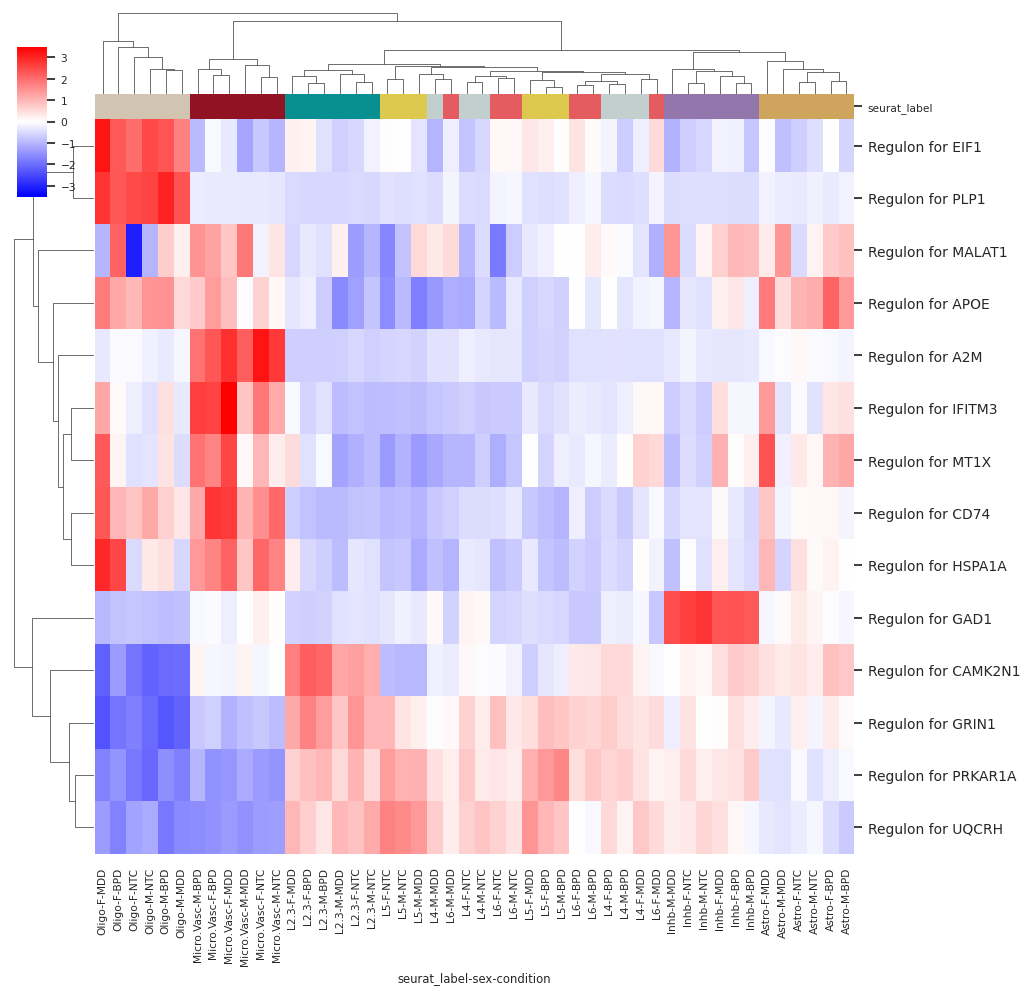

In [11]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['seurat_label','sex','condition']]
df_means = df_scores.groupby(by=['seurat_label','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['seurat_label'] = [x[0] for x in df_means.index]
row_colors = colors_df['seurat_label'].map(transfer_bright)

hmp = sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.1,
               cmap='bwr', vmin=-3.5, vmax=3.5,
              cbar_pos=(0.02, 0.8, 0.03, 0.15))
hmp.ax_heatmap.set_yticklabels(hmp.ax_heatmap.get_ymajorticklabels(), fontsize = 10)

#hmp.figure.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-seurat-pc30.pdf')

plt.show()

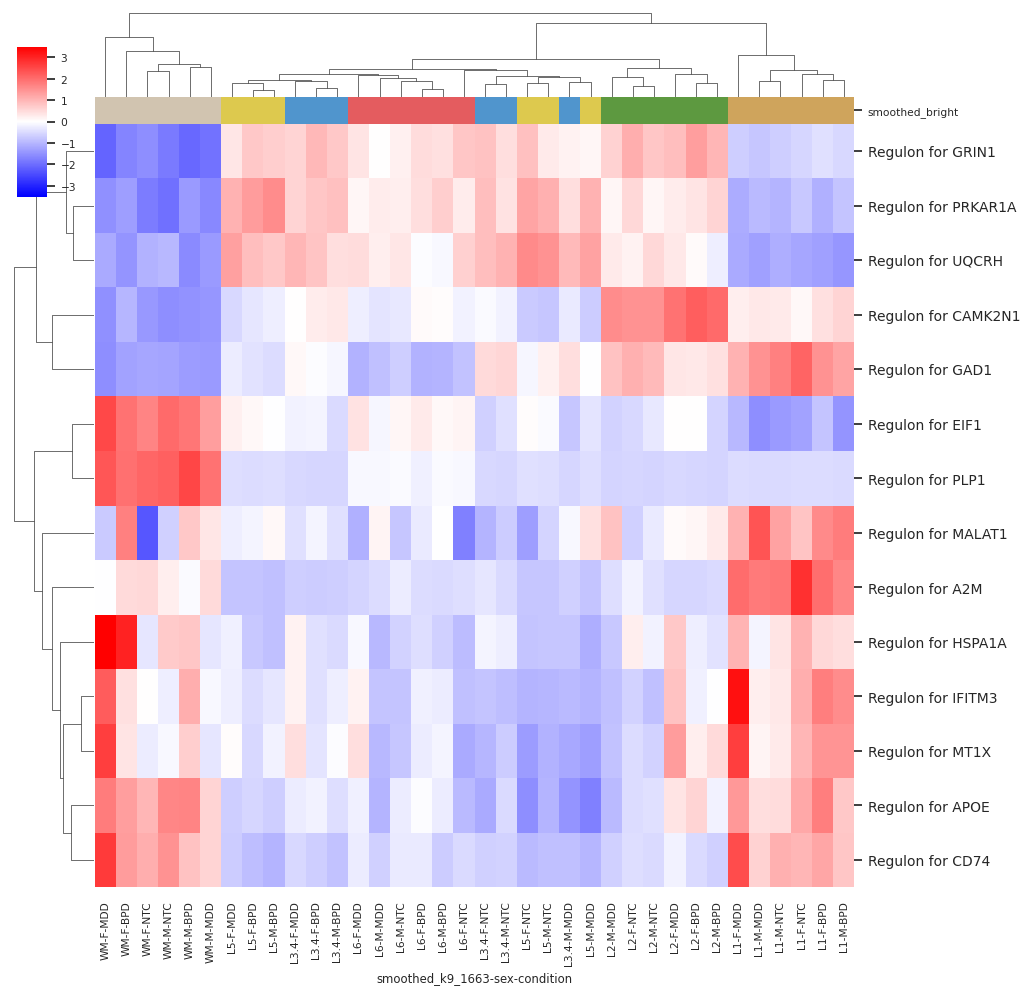

In [12]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['smoothed_k9_1663','sex','condition']]
df_scores = df_scores.loc[-df_scores['smoothed_k9_1663'].isin(['Vasc','GABA'])]
df_means = df_scores.groupby(by=['smoothed_k9_1663','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['smoothed_bright'] = [x[0] for x in df_means.index]
row_colors = colors_df['smoothed_bright'].map(smoothed_bright)

hmp = sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.1,
               cmap='bwr', vmin=-3.5, vmax=3.5,
              cbar_pos=(0.02, 0.8, 0.03, 0.15))
hmp.ax_heatmap.set_yticklabels(hmp.ax_heatmap.get_ymajorticklabels(), fontsize = 10)

#hmp.figure.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-smoothed-k9-1663.pdf')

plt.show()

In [13]:
import numpy as np
auc_corr = np.corrcoef(auc_all.T)
corrDF = pd.DataFrame(auc_corr, index=auc_all.columns, columns= auc_all.columns)
corrDF.head()

,Regulon for A2M,Regulon for APOE,Regulon for CAMK2N1,Regulon for CD74,Regulon for EIF1,Regulon for GAD1,Regulon for GRIN1,Regulon for HSPA1A,Regulon for IFITM3,Regulon for MALAT1,Regulon for MT1X,Regulon for PLP1,Regulon for PRKAR1A,Regulon for UQCRH
Regulon for A2M,1.000000,0.084209,-0.029599,0.117974,0.009625,0.029776,-0.080539,0.135271,0.225188,-0.001151,0.119672,0.020586,-0.086060,-0.141104
Regulon for APOE,0.084209,1.000000,-0.031625,0.090350,0.333306,-0.024332,0.013525,0.192217,0.250344,-0.058132,0.454718,0.142004,-0.106757,-0.119372
Regulon for CAMK2N1,-0.029599,-0.031625,1.000000,-0.034729,-0.086364,-0.014084,0.221504,-0.011981,-0.023961,0.056082,-0.004879,-0.140917,0.073604,-0.075043
Regulon for CD74,0.117974,0.090350,-0.034729,1.000000,0.043192,-0.004348,-0.096523,0.102760,0.203308,0.005421,0.141642,0.101264,-0.088044,-0.138161
Regulon for EIF1,0.009625,0.333306,-0.086364,0.043192,1.000000,-0.083544,0.056291,0.097907,0.104803,-0.139123,0.166084,0.414868,-0.066318,0.289785


In [14]:
corrDF.to_csv(pdir+"processed-data/09_DEG_GRN/spe-n119_13162-no-lowUMI_modules-DEG-subset-refined_AUCell-correlation.csv")

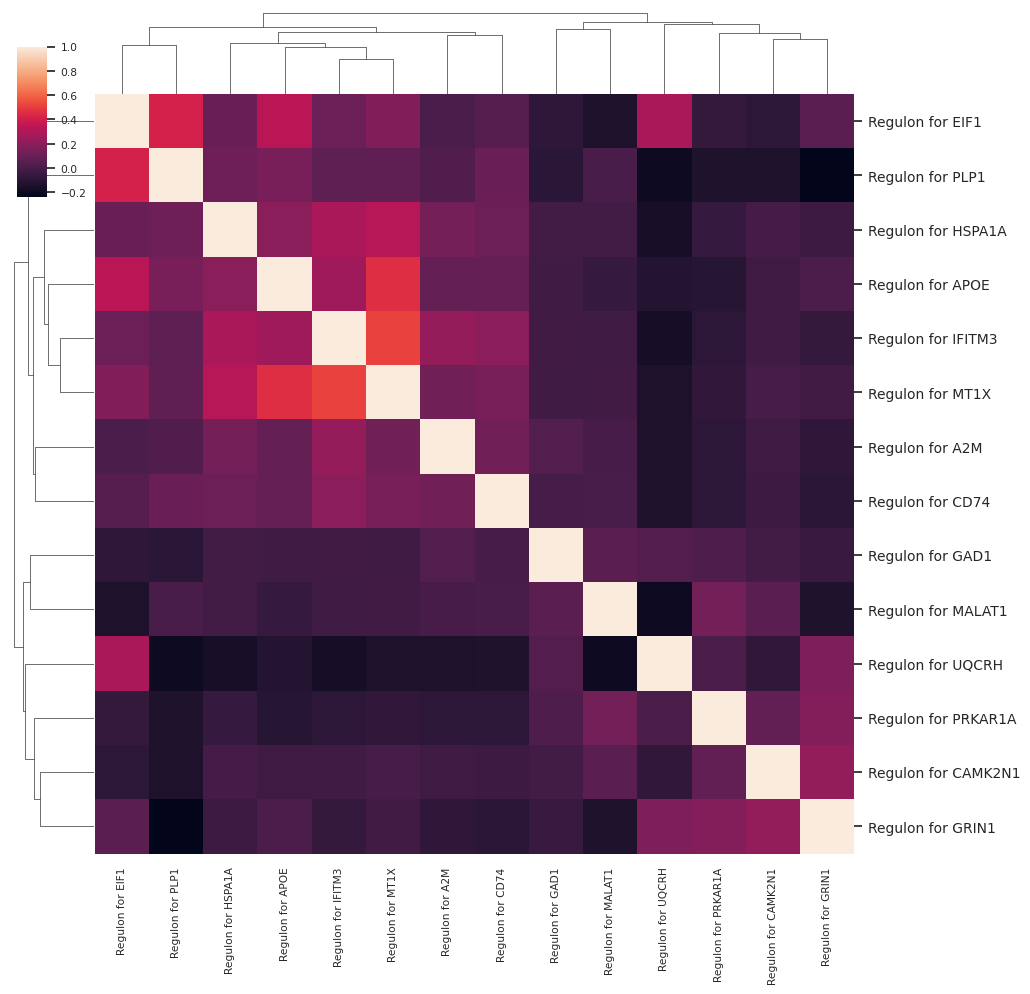

In [15]:
hmp = sns.clustermap(corrDF, dendrogram_ratio=.1,
                    cbar_pos=(0.02, 0.8, 0.03, 0.15))
hmp.ax_heatmap.set_yticklabels(hmp.ax_heatmap.get_ymajorticklabels(), fontsize = 10)

#hmp.figure.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-correlation.pdf')

plt.show()

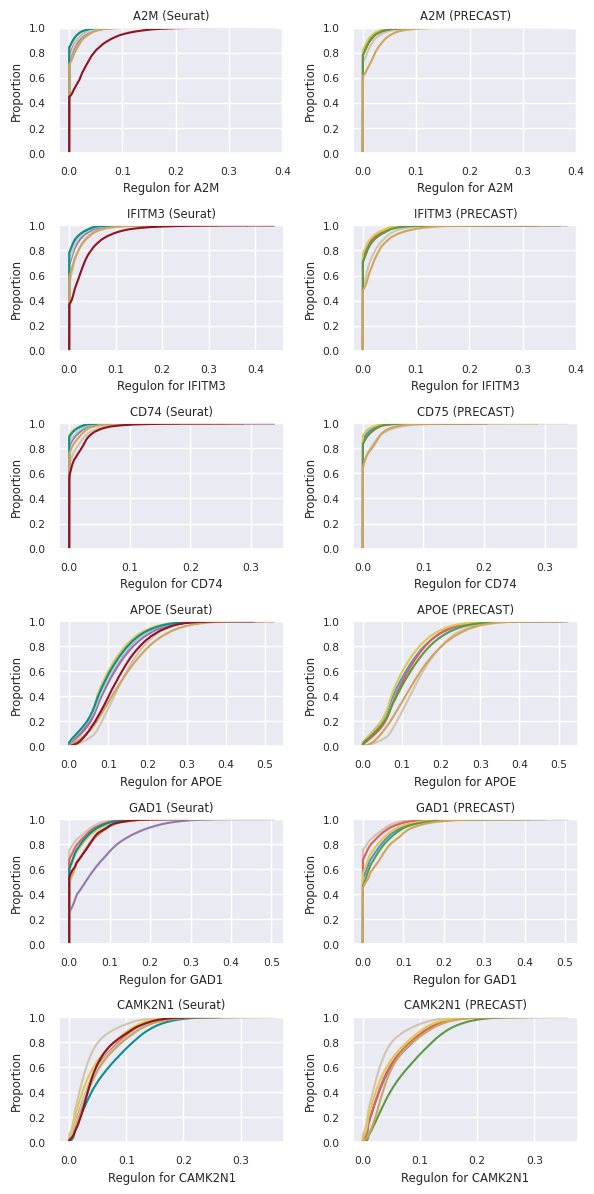

In [18]:
fig, axs = plt.subplots(6, 2, figsize=(6, 12))

axs = axs.flatten()

sns.ecdfplot(data=joined_all, x="Regulon for A2M", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[0])
axs[0].set_title("A2M (Seurat)")
sns.ecdfplot(data=joined_precast, x="Regulon for A2M", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[1])
axs[1].set_title("A2M (PRECAST)")

sns.ecdfplot(data=joined_all, x="Regulon for IFITM3", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[2])
axs[2].set_title("IFITM3 (Seurat)")
sns.ecdfplot(data=joined_precast, x="Regulon for IFITM3", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[3])
axs[3].set_title("IFITM3 (PRECAST)")

sns.ecdfplot(data=joined_all, x="Regulon for CD74", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[4])
axs[4].set_title("CD74 (Seurat)")
sns.ecdfplot(data=joined_precast, x="Regulon for CD74", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[5])
axs[5].set_title("CD75 (PRECAST)")

sns.ecdfplot(data=joined_all, x="Regulon for APOE", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[6])
axs[6].set_title("APOE (Seurat)")
sns.ecdfplot(data=joined_precast, x="Regulon for APOE", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[7])
axs[7].set_title("APOE (PRECAST)")

sns.ecdfplot(data=joined_all, x="Regulon for GAD1", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[8])
axs[8].set_title("GAD1 (Seurat)")
sns.ecdfplot(data=joined_precast, x="Regulon for GAD1", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[9])
axs[9].set_title("GAD1 (PRECAST)")

sns.ecdfplot(data=joined_all, x="Regulon for CAMK2N1", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[10])
axs[10].set_title("CAMK2N1 (Seurat)")
sns.ecdfplot(data=joined_precast, x="Regulon for CAMK2N1", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[11])
axs[11].set_title("CAMK2N1 (PRECAST)")

plt.tight_layout()
#plt.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-layers-ecdf.pdf', 
#            bbox_inches='tight')
plt.show()

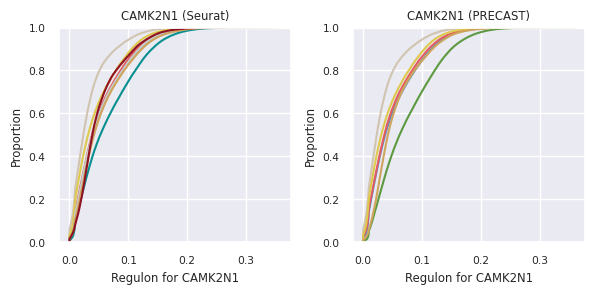

In [19]:
gene1 = "Regulon for CAMK2N1"

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title("CAMK2N1 (Seurat)")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title("CAMK2N1 (PRECAST)")

plt.tight_layout()

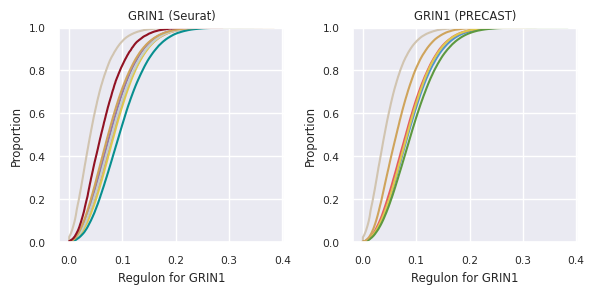

In [20]:
gene1 = "Regulon for GRIN1"

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title("GRIN1 (Seurat)")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title("GRIN1 (PRECAST)")

plt.tight_layout()

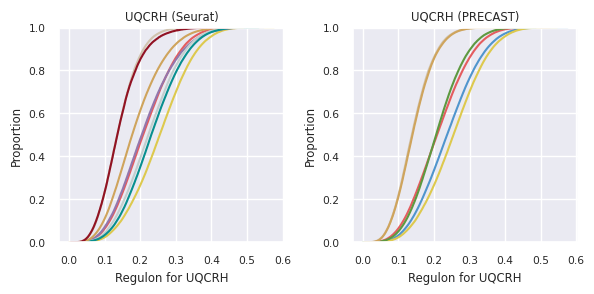

In [21]:
gene1 = "Regulon for UQCRH"

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title("UQCRH (Seurat)")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title("UQCRH (PRECAST)")

plt.tight_layout()

In [22]:
len(auc_all.columns)

14

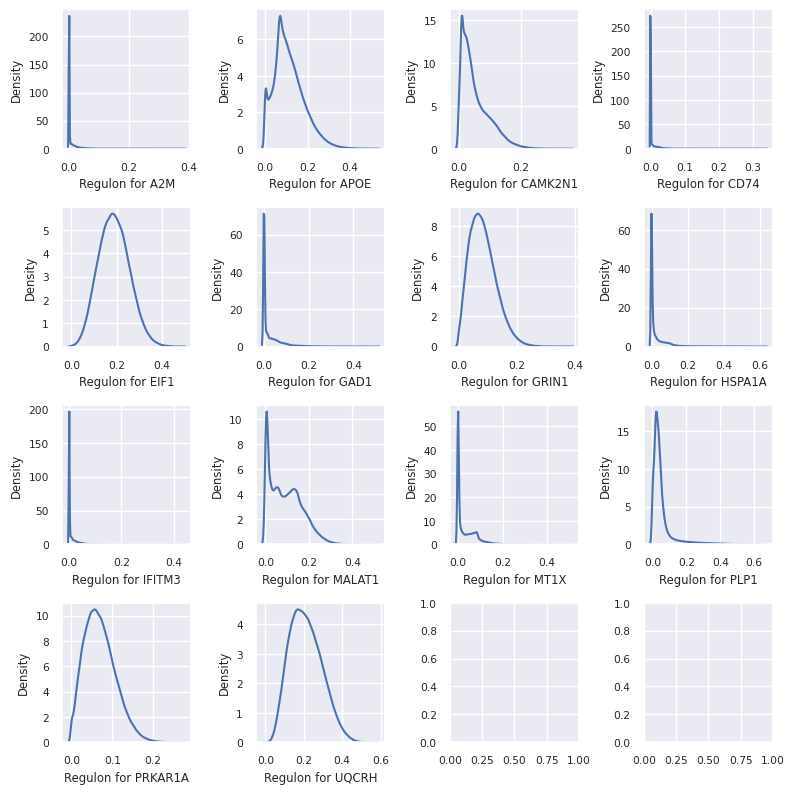

In [23]:
fig, axs = plt.subplots(4, 4, figsize=(8, 8))

axs_flat = axs.flatten()

for i in range(14):
    gene1 = auc_all.columns[i]
    
    sns.kdeplot(data=joined_all, x=gene1, ax=axs_flat[i])

plt.tight_layout()
#plt.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-density.pdf', 
#            bbox_inches='tight')
plt.show()